| 4 | Drop correlated features | all implies same results + increase comlexity |
| 5 | Encode labels | Binary (0/1) + multi-class integer for post-hoc analysis |
| 6 | StandardScaler | Required for t-SNE; improves IF tree construction |
| 7 | Low-variance filter | Constant or near-constant features carry no information |
| 8 | Correlation filter (\|r\| > 0.95) | Redundant features inflate dimension without adding signal |

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv("C:\\Users\\abdul\\projects\\n_a_i_d\\data\\processed\\processed_merged.csv")
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [9]:
df["Label"].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [11]:
attack_count = df["Label"].value_counts().drop("BENIGN").sum()
print(attack_count)

557646


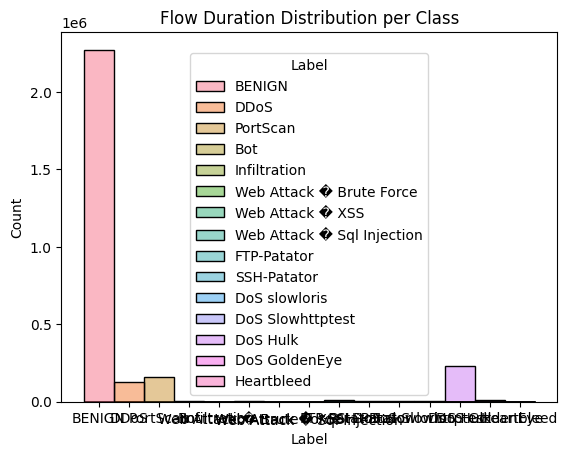

In [12]:
sns.histplot(
    data=df,
    x="Label",
    hue="Label",
    bins=50,
    kde=True
)

plt.title("Flow Duration Distribution per Class")
plt.show()

In [13]:
# 1. Separate
benign_df = df[df["Label"] == "BENIGN"]
attack_df = df[df["Label"] != "BENIGN"]

# 2. Reduce benign
benign_reduced = benign_df.sample(
    n=len(benign_df) - 1773097,
    random_state=42
)

# 3. Combine
df = pd.concat([benign_reduced, attack_df], ignore_index=True)

# 4. Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Check
print(df.shape)

(1057646, 79)


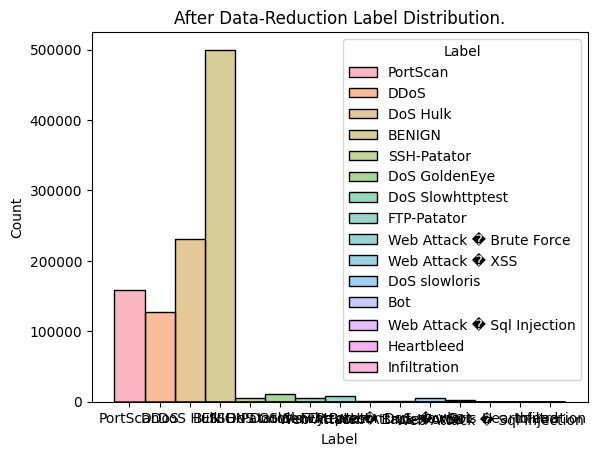

In [14]:


sns.histplot(
    data=df,
    x="Label",
    hue="Label",
    bins=50,
    kde=True,
)

sns.barplot()
plt.title("After Data-Reduction Label Distribution.")
plt.show()



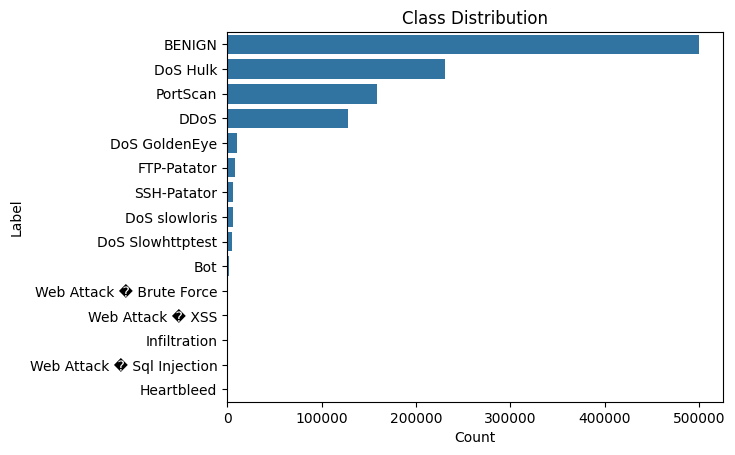

In [15]:

counts = df["Label"].value_counts()

sns.barplot(
    x=counts.values,
    y=counts.index
)

plt.title("Class Distribution")
plt.xlabel("Count")
plt.ylabel("Label")
plt.show()